# Waste Product Classification Using Transfer Learning (VGG16)

Classifies waste images into **Organic (O)** and **Recyclable (R)** using fine-tuned VGG16.

VGG16 is pretrained on ImageNet. The last convolutional block (`block5_conv3` onwards) is unfrozen so the model adapts its deeper features to the waste domain, while a custom Dense head handles the binary classification.


## 1. Install Dependencies

In [2]:
!pip install -q tensorflow==2.21.0
!pip install -q numpy
!pip install -q scikit-learn
!pip install -q matplotlib==3.9.2


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2. Import Libraries

In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import vgg16
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 3. Download Dataset

Dataset: ~1200 waste images split into `train/` and `test/`, each with `O/` (organic) and `R/` (recyclable) subfolders.

In [4]:
import requests
import zipfile
from tqdm import tqdm

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/kd6057VPpABQ2FqCbgu9YQ/o-vs-r-split-reduced-1200.zip"
file_name = "o-vs-r-split-reduced-1200.zip"

print("Downloading dataset...")
with requests.get(url, stream=True) as response:
    response.raise_for_status()
    with open(file_name, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)

print("Extracting...")
with zipfile.ZipFile(file_name, 'r') as zip_ref:
    members = zip_ref.infolist()
    with tqdm(total=len(members), unit='file') as pbar:
        for member in members:
            zip_ref.extract(member)
            pbar.update(1)

os.remove(file_name)
print("Done.")

Extracting...


100%|██████████| 1207/1207 [00:00<00:00, 1399.30file/s]

Done.


## 4. Configuration

In [5]:
img_rows, img_cols = 150, 150
batch_size = 32
n_epochs = 10
val_split = 0.2
path_train = 'o-vs-r-split/train/'
path_test = 'o-vs-r-split/test/'
input_shape = (img_rows, img_cols, 3)
seed = 42

## 5. Data Generators

Training data is augmented (horizontal flip, small shifts) to improve generalization. All images are rescaled to [0, 1].

In [6]:
train_datagen = ImageDataGenerator(
    validation_split=val_split,
    rescale=1.0/255.0,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    validation_split=val_split,
    rescale=1.0/255.0
)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    directory=path_train, seed=seed, batch_size=batch_size,
    class_mode='binary', shuffle=True,
    target_size=(img_rows, img_cols), subset='training'
)

val_generator = val_datagen.flow_from_directory(
    directory=path_train, seed=seed, batch_size=batch_size,
    class_mode='binary', shuffle=True,
    target_size=(img_rows, img_cols), subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    directory=path_test, class_mode='binary', seed=seed,
    batch_size=batch_size, shuffle=False,
    target_size=(img_rows, img_cols)
)

print(f'Train batches: {len(train_generator)}, Val batches: {len(val_generator)}, Test batches: {len(test_generator)}')

Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Train batches: 25, Val batches: 7, Test batches: 7


## 6. Build Model

Load VGG16 pretrained on ImageNet, unfreeze from `block5_conv3` onwards, and attach a binary classification head.

In [7]:
base_vgg = vgg16.VGG16(include_top=False, weights='imagenet', input_shape=input_shape)
output = tf.keras.layers.Flatten()(base_vgg.layers[-1].output)
basemodel = Model(base_vgg.input, output)

# Freeze all layers, then unfreeze from block5_conv3 onwards
set_trainable = False
for layer in basemodel.layers:
    if layer.name == 'block5_conv3':
        set_trainable = True
    layer.trainable = set_trainable

model = Sequential([
    basemodel,
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional (Functional)         │ (None, 8192)           │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,910,017 (72.14 MB)

 Trainable params: 6,555,137 (25.01 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

## 7. Train Model

In [8]:
class LossHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.losses = []
    def on_batch_end(self, batch, logs={}):
        self.losses.append(logs.get('loss'))

def exp_decay(epoch):
    return 0.01 * math.exp(-0.1 * epoch)

callbacks = [
    LossHistory(),
    LearningRateScheduler(exp_decay),
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ModelCheckpoint('waste_classifier_vgg16.keras', monitor='val_loss', save_best_only=True)
]

history = model.fit(
    train_generator,
    steps_per_epoch=5,
    epochs=n_epochs,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5562 - loss: 3725.2427 - val_accuracy: 0.5000 - val_loss: 54.8022 - learning_rate: 0.0100
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4875 - loss: 36.7608 - val_accuracy: 0.5050 - val_loss: 29.6250 - learning_rate: 0.0090
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6500 - loss: 6.6872 - val_accuracy: 0.5300 - val_loss: 3.2927 - learning_rate: 0.0082
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.7250 - loss: 2.1024 - val_accuracy: 0.5600 - val_loss: 4.2175 - learning_rate: 0.0074
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6938 - loss: 2.3934 - val_accuracy: 0.8600 - val_loss: 0.3789 - learning_rate: 0.0067
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7625 - loss: 0.8967 - val_accuracy: 0.8300 - val_loss: 0.4615 - learning_rate: 0.0061
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.7937 - loss: 0.6274 - val_accuracy: 0.6800 - val_l

## 8. Training Curves

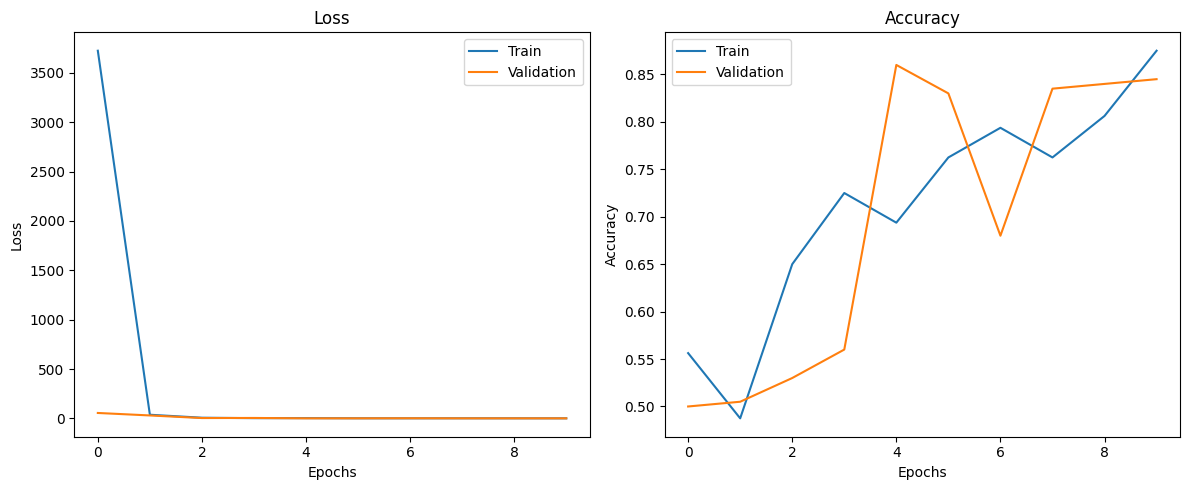

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Evaluate on Test Set

In [12]:
model = tf.keras.models.load_model('waste_classifier_vgg16.keras')

raw_preds = model.predict(test_generator, verbose=0)
predictions = ['O' if p < 0.5 else 'R' for p in raw_preds]
true_labels = ['O' if l == 0 else 'R' for l in test_generator.classes]

print(metrics.classification_report(true_labels, predictions, target_names=['Organic (O)', 'Recyclable (R)']))

                precision    recall  f1-score   support

   Organic (O)       0.82      0.79      0.81       100
Recyclable (R)       0.80      0.83      0.81       100

      accuracy                           0.81       200
     macro avg       0.81      0.81      0.81       200
  weighted avg       0.81      0.81      0.81       200



## 10. Visualize Sample Predictions

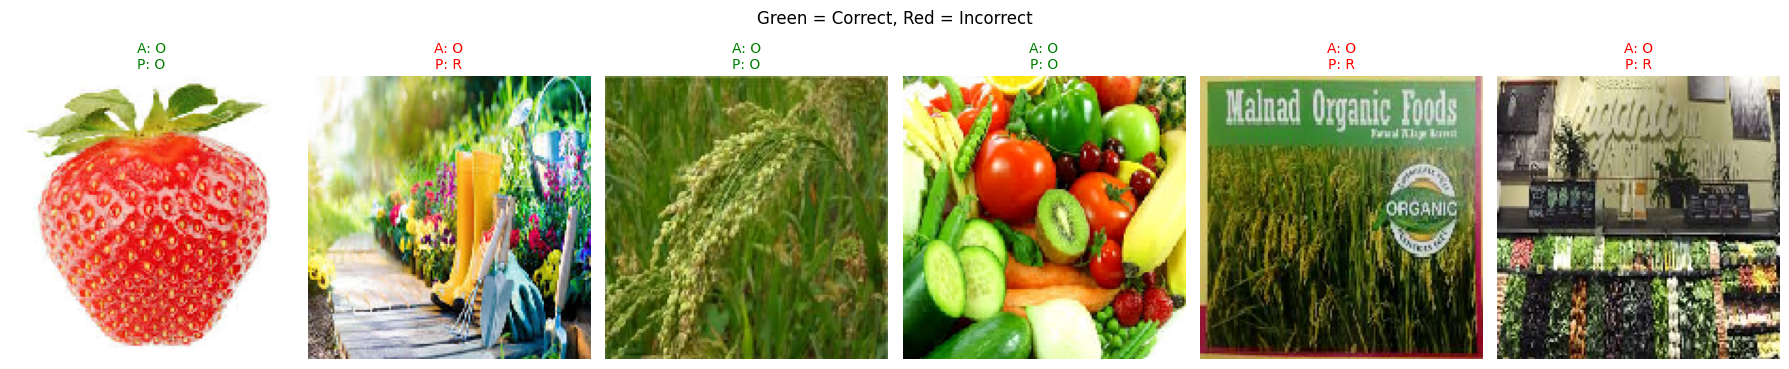

In [13]:
n_samples = 6

fig, axes = plt.subplots(1, n_samples, figsize=(18, 4))
for i in range(n_samples):
    img_path = test_generator.filepaths[i]
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(img_rows, img_cols))
    axes[i].imshow(img)
    actual = true_labels[i]
    predicted = predictions[i]
    color = 'green' if actual == predicted else 'red'
    axes[i].set_title(f'A: {actual}\nP: {predicted}', color=color, fontsize=10)
    axes[i].axis('off')

plt.suptitle('Green = Correct, Red = Incorrect', fontsize=12)
plt.tight_layout()
plt.show()